
Temperaturas no dataset:
[np.int64(25), np.int64(35), np.int64(45)]

Contagem por temperatura:
temperature_C
25    81
35    72
45    72
Name: count, dtype: int64
Temp 25°C → 81 linhas
Temp 35°C → 72 linhas
Temp 45°C → 72 linhas


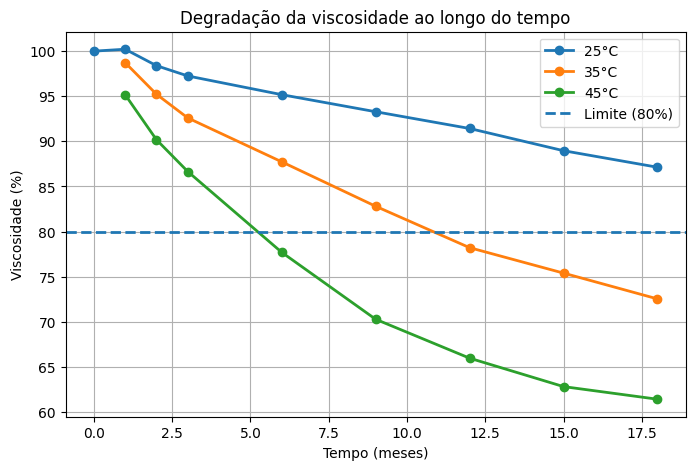


=== RESULTADOS ===
   temperature_C     slope  intercept        r2  t_80_months
0             25 -0.728077  99.987063  0.991427    27.451863
1             35 -1.513255  97.885458  0.976474    11.819200
2             45 -2.005727  92.816022  0.933255     6.389713
   temperature_C     slope  intercept        r2  t_80_months  temp_K  \
0             25 -0.728077  99.987063  0.991427    27.451863  298.15   
1             35 -1.513255  97.885458  0.976474    11.819200  308.15   
2             45 -2.005727  92.816022  0.933255     6.389713  318.15   

          k      ln_k     inv_T  
0  0.728077 -0.317349  0.003354  
1  1.513255  0.414263  0.003245  
2  2.005727  0.696007  0.003143  

Arrhenius model:
Slope: -4827.549177514938
Intercept: 15.941548643309059
R²: 0.9470573683831717


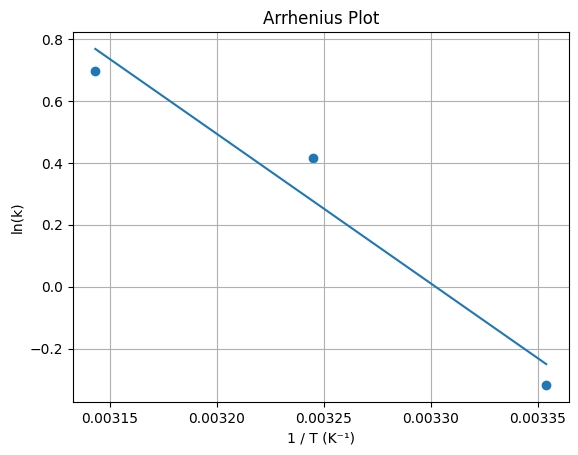

                                   mean         std      cv_%
temperature_C time_months                                    
25            0            19978.111111  217.908493  1.090736
              1            20019.444444  147.322869  0.735899
              2            19654.555556   43.655215  0.222112
              3            19426.666667   32.338058  0.166462
              6            19012.222222   16.716592  0.087926
              9            18634.333333   34.803017  0.186768
              12           18263.333333   44.827447  0.245451
              15           17770.444444  194.139841  1.092487
              18           17406.222222  210.713536  1.210564
35            1            19720.555556  179.259666  0.908999
              2            19021.444444   13.106402  0.068903
              3            18497.111111   56.994395  0.308126
              6            17524.888889   19.412911  0.110773
              9            16540.777778   33.089945  0.200051
        

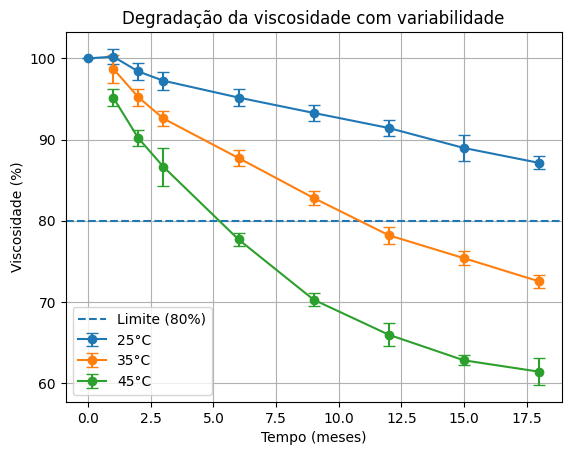

'Viscosity degradation with temperature (mean ± std)'

In [9]:
# ==============================
# 1. IMPORTS
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 2. LOAD DATA
# ==============================
df = pd.read_excel("../data/raw/shelflife_data.xlsx")

# ==============================
# 3. CLEANING
# ==============================

# remover coluna lixo do Excel
if "Unnamed: 5" in df.columns:
    df = df.drop(columns=["Unnamed: 5"])

# corrigir batch (preencher vazios)
df["batch"] = df["batch"].replace("", np.nan)
df["batch"] = df["batch"].ffill()

# garantir temperatura numérica limpa
df["temperature_C"] = (
    df["temperature_C"]
    .astype(str)
    .str.replace("°C", "", regex=False)
    .str.replace("C", "", regex=False)
    .str.strip()
)

df["temperature_C"] = pd.to_numeric(df["temperature_C"], errors="coerce")

# ==============================
# 4. BASELINE CORRETO (tempo 0)
# ==============================

# NÃO usa temperatura aqui (correção crítica)
initial = (
    df[df["time_months"] == 0]
    [["batch", "replicate", "viscosity_cP"]]
    .rename(columns={"viscosity_cP": "viscosity_initial"})
)

# merge correto
df = df.merge(
    initial,
    on=["batch", "replicate"],
    how="left"
)

# ==============================
# 5. CALCULAR % VISCOSIDADE
# ==============================
df["viscosity_pct"] = (df["viscosity_cP"] / df["viscosity_initial"]) * 100

# ==============================
# 6. DEBUG RÁPIDO
# ==============================
print("\nTemperaturas no dataset:")
print(sorted(df["temperature_C"].dropna().unique()))

print("\nContagem por temperatura:")
print(df["temperature_C"].value_counts())

# ==============================
# 7. GRÁFICO FINAL (PROFISSIONAL)
# ==============================

plt.figure(figsize=(8,5))

temps = sorted(df["temperature_C"].dropna().unique())

for temp in temps:
    
    subset = df[df["temperature_C"] == temp].copy()
    
    print(f"Temp {temp}°C → {len(subset)} linhas")
    
    if subset.empty:
        continue
    
    mean_data = (
        subset.groupby("time_months")["viscosity_pct"]
        .mean()
        .sort_index()
    )
    
    plt.plot(
        mean_data.index,
        mean_data.values,
        marker='o',
        linewidth=2,
        label=f"{int(temp)}°C"
    )

# limite crítico (queda de 20%)
plt.axhline(80, linestyle="--", linewidth=2, label="Limite (80%)")

plt.xlabel("Tempo (meses)")
plt.ylabel("Viscosidade (%)")
plt.title("Degradação da viscosidade ao longo do tempo")
plt.legend()
plt.grid()

plt.show()
# ==============================
# 8. MODELAGEM (tempo até 80%)
# ==============================

from scipy.stats import linregress

results = []

temps = sorted(df["temperature_C"].dropna().unique())

for temp in temps:
    
    subset = df[df["temperature_C"] == temp]
    
    # média por tempo
    mean_data = (
        subset.groupby("time_months")["viscosity_pct"]
        .mean()
        .sort_index()
    )
    
    x = mean_data.index.values  # tempo
    y = mean_data.values        # viscosidade
    
    # regressão linear
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    
    # calcular tempo quando y = 80%
    # 80 = slope*x + intercept
    t_80 = (80 - intercept) / slope
    
    results.append({
        "temperature_C": temp,
        "slope": slope,
        "intercept": intercept,
        "r2": r_value**2,
        "t_80_months": t_80
    })

results_df = pd.DataFrame(results)

print("\n=== RESULTADOS ===")
print(results_df)
# ==============================
# ARRHENIUS MODEL
# ==============================

import numpy as np
import pandas as pd
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Copiar resultados anteriores
arr = pd.DataFrame(results)

# Converter temperatura para Kelvin
arr["temp_K"] = arr["temperature_C"] + 273.15

# k = -slope (taxa positiva)
arr["k"] = -arr["slope"]

# Transformações Arrhenius
arr["ln_k"] = np.log(arr["k"])
arr["inv_T"] = 1 / arr["temp_K"]

print(arr)

# ==============================
# REGRESSÃO ARRHENIUS
# ==============================

slope, intercept, r_value, _, _ = linregress(arr["inv_T"], arr["ln_k"])

print("\nArrhenius model:")
print("Slope:", slope)
print("Intercept:", intercept)
print("R²:", r_value**2)

# ==============================
# GRÁFICO ARRHENIUS
# ==============================

plt.figure()

plt.scatter(arr["inv_T"], arr["ln_k"])

# linha ajustada
x = np.linspace(arr["inv_T"].min(), arr["inv_T"].max(), 100)
y = slope * x + intercept

plt.plot(x, y)

plt.xlabel("1 / T (K⁻¹)")
plt.ylabel("ln(k)")
plt.title("Arrhenius Plot")

plt.grid()
plt.show()
df.groupby(["temperature_C", "time_months"])["viscosity_cP"].std()
grouped = df.groupby(["temperature_C", "time_months"])["viscosity_cP"]

stats = grouped.agg(["mean", "std"])
stats["cv_%"] = (stats["std"] / stats["mean"]) * 100

print(stats)
import matplotlib.pyplot as plt

# ==============================
# AGRUPAR DADOS (média + desvio)
# ==============================

grouped = df.groupby(["temperature_C", "time_months"])["viscosity_pct"]

stats = grouped.agg(["mean", "std"]).reset_index()

# ==============================
# GRÁFICO COM BARRA DE ERRO
# ==============================

plt.figure()

temps = sorted(stats["temperature_C"].unique())

for temp in temps:
    subset = stats[stats["temperature_C"] == temp]
    
    plt.errorbar(
        subset["time_months"],
        subset["mean"],
        yerr=subset["std"],
        marker='o',
        capsize=4,
        label=f"{temp}°C"
    )

# linha limite 80%
plt.axhline(80, linestyle='--', label="Limite (80%)")

# layout
plt.xlabel("Tempo (meses)")
plt.ylabel("Viscosidade (%)")
plt.title("Degradação da viscosidade com variabilidade")
plt.legend()
plt.grid()

plt.show()
"Viscosity degradation with temperature (mean ± std)"